In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

In [44]:
df = pd.read_csv("Loan_Default.csv")
df.head()

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


In [45]:
df.shape

(148670, 34)

In [46]:
df.isnull().sum()

ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score                     0
co-applicant_credit_type         0
age                            200
submission_of_applic

In [47]:
df.duplicated().sum()

np.int64(0)

In [48]:
print(df["Status"].value_counts(dropna=False))
print(df["Status"].value_counts(normalize=True, dropna=False).mul(100).round(2))

Status
0    112031
1     36639
Name: count, dtype: int64
Status
0    75.36
1    24.64
Name: proportion, dtype: float64


In [49]:
df = df.drop(columns=["ID", "year"], errors="ignore")
invalid_filters = {
    "Security_Type": "Indriect",
    "open_credit": "opc",
    "construction_type": "mh",
    "Secured_by": "opc"
}
for col, bad_value in invalid_filters.items():
    if col in df.columns:
        df = df[df[col].astype(str).str.strip().str.lower() != str(bad_value).strip().lower()]
df = df.drop(
    columns=["open_credit", "construction_type", "Secured_by", "Security_Type"],
    errors="ignore"
)
df = df.dropna(subset=["Status"]).reset_index(drop=True)
print("Shape after cleaning:", df.shape)
print("Missing values in target:", df["Status"].isna().sum())


Shape after cleaning: (148081, 28)
Missing values in target: 0


In [50]:
x = df.drop(columns=["Status"])
y = df["Status"].astype(int)
xtr, xte, ytr, yte = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training shape:", xtr.shape)
print("Testing shape :", xte.shape)


Training shape: (118464, 27)
Testing shape : (29617, 27)


In [51]:
outlier_cols = [
    "loan_amount",
    "rate_of_interest",
    "Interest_rate_spread",
    "Upfront_charges",
    "term",
    "property_value",
    "income",
    "LTV"
]
outlier_cols = [c for c in outlier_cols if c in xtr.columns]
def get_iqr_limits(train_df, columns):
    limits = {}
    for col in columns:
        series = pd.to_numeric(train_df[col], errors="coerce")
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        limits[col] = (q1 - 1.5 * iqr, q3 + 1.5 * iqr)
    return limits
iqr_limits = get_iqr_limits(xtr, outlier_cols)
def cap_using_limits(data, limits):
    data = data.copy()
    for col, (low, high) in limits.items():
        data[col] = pd.to_numeric(data[col], errors="coerce").clip(low, high)
    return data
xtr = cap_using_limits(xtr, iqr_limits)
xte = cap_using_limits(xte, iqr_limits)
print("Outlier-capped numerical columns:", outlier_cols)


Outlier-capped numerical columns: ['loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'property_value', 'income', 'LTV']


In [52]:
num_cols = xtr.select_dtypes(include=np.number).columns.tolist()
cat_cols = xtr.select_dtypes(exclude=np.number).columns.tolist()
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
prep = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols)
])
print("Numerical features:", len(num_cols))
print("Categorical features:", len(cat_cols))


Numerical features: 10
Categorical features: 17


In [53]:
models = {
    "Logistic Regression": Pipeline([
        ("prep", prep),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ])
}

res = []
fitted_models = {}

for name, pipeline in models.items():
    pipeline.fit(xtr, ytr)

    pred = pipeline.predict(xte)
    prob = pipeline.predict_proba(xte)[:, 1]

    res.append({
        "Model": name,
        "Accuracy": accuracy_score(yte, pred),
        "Precision": precision_score(yte, pred, zero_division=0),
        "Recall": recall_score(yte, pred, zero_division=0),
        "F1": f1_score(yte, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(yte, prob)
    })

    fitted_models[name] = pipeline

results_df = (
    pd.DataFrame(res)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

display(results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8353,0.6532,0.7078,0.6794,0.8634


In [54]:
logistic_pipeline = Pipeline([
    ("prep", prep),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=3000,
        random_state=42
    ))
])

param_distributions = {
    "model__C": np.logspace(-2, 2, 12),
    "model__solver": ["liblinear", "lbfgs"]
}

search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(xtr, ytr)

print("Best parameters:", search.best_params_)
print("Best cross-validation F1:", round(search.best_score_, 4))

tuned_model = search.best_estimator_

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best parameters: {'model__solver': 'lbfgs', 'model__C': np.float64(0.2848035868435802)}
Best cross-validation F1: 0.6798


In [55]:
pred = tuned_model.predict(xte)
prob = tuned_model.predict_proba(xte)[:, 1]

print("Accuracy:", round(accuracy_score(yte, pred), 4))
print("Precision:", round(precision_score(yte, pred, zero_division=0), 4))
print("Recall:", round(recall_score(yte, pred, zero_division=0), 4))
print("F1:", round(f1_score(yte, pred, zero_division=0), 4))
print("ROC-AUC:", round(roc_auc_score(yte, prob), 4))

Accuracy: 0.8357
Precision: 0.6541
Recall: 0.7079
F1: 0.68
ROC-AUC: 0.8635


In [56]:
print(classification_report(yte, pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.90      0.88      0.89     22315
           1       0.65      0.71      0.68      7302

    accuracy                           0.84     29617
   macro avg       0.78      0.79      0.78     29617
weighted avg       0.84      0.84      0.84     29617



<Figure size 600x500 with 0 Axes>

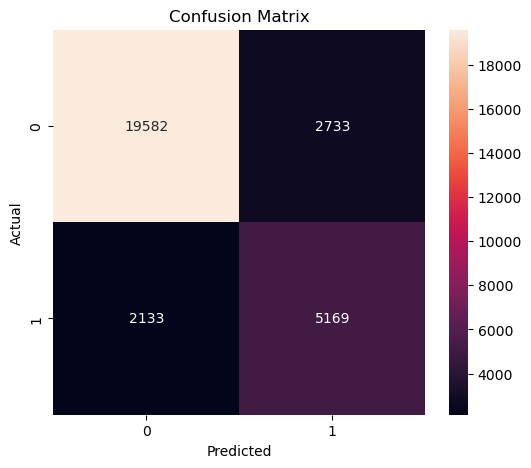

In [57]:
cm = confusion_matrix(yte, pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [58]:
fpr, tpr, _ = roc_curve(yte, prob)
auc = roc_auc_score(yte, prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

NameError: name 'roc_curve' is not defined

In [59]:
sample = xte.iloc[[0]]

print("Actual:", yte.iloc[0])
print("Predicted:", tuned_model.predict(sample)[0])

Actual: 0
Predicted: 0


In [60]:
sample = xte.iloc[[0]]

print("Actual:", yte.iloc[0])
print("Predicted:", tuned_model.predict(sample)[0])

Actual: 0
Predicted: 0


In [61]:
sample = pd.DataFrame([{
    "loan_limit": "cf",
    "Gender": "Male",
    "approv_in_adv": "pre",
    "loan_type": "type1",
    "loan_purpose": "p2",
    "Credit_Worthiness": "l1",
    "business_or_commercial": "nob/c",
    "loan_amount": 180000,
    "rate_of_interest": 3.25,
    "Interest_rate_spread": 0.25,
    "Upfront_charges": 2500,
    "term": 360,
    "Neg_ammortization": "not_neg",
    "interest_only": "not_int",
    "lump_sum_payment": "not_lpsm",
    "property_value": 300000,
    "occupancy_type": "pr",
    "total_units": "1U",
    "income": 8500,
    "credit_type": "EXP",
    "Credit_Score": 790,
    "co-applicant_credit_type": "CIB",
    "age": "35-44",
    "submission_of_application": "to_inst",
    "LTV": 60.0,
    "Region": "North",
    "dtir1": 28.0
}])

pred = tuned_model.predict(sample)[0]
prob = tuned_model.predict_proba(sample)[0, 1]

print("Predicted Status:", pred)
print("Default Probability:", round(prob, 4))

Predicted Status: 0
Default Probability: 0.4449


In [62]:
sample = pd.DataFrame([{
    "loan_limit": "cf",
    "Gender": "Female",
    "approv_in_adv": "nopre",
    "loan_type": "type2",
    "loan_purpose": "p3",
    "Credit_Worthiness": "l2",
    "business_or_commercial": "b/c",
    "loan_amount": 450000,
    "rate_of_interest": 7.25,
    "Interest_rate_spread": 3.10,
    "Upfront_charges": 12000,
    "term": 360,
    "Neg_ammortization": "neg_amm",
    "interest_only": "int_only",
    "lump_sum_payment": "lpsm",
    "property_value": 500000,
    "occupancy_type": "pr",
    "total_units": "1U",
    "income": 2800,
    "credit_type": "EQUI",
    "Credit_Score": 510,
    "co-applicant_credit_type": "EXP",
    "age": "25-34",
    "submission_of_application": "not_inst",
    "LTV": 90.0,
    "Region": "south",
    "dtir1": 55.0
}])

pred = tuned_model.predict(sample)[0]
prob = tuned_model.predict_proba(sample)[0, 1]

print("Predicted Status:", pred)
print("Default Probability:", round(prob, 4))

Predicted Status: 1
Default Probability: 0.9977


In [63]:
sample = pd.DataFrame([{
    "loan_limit": "cf",
    "Gender": "Joint",
    "approv_in_adv": "pre",
    "loan_type": "type1",
    "loan_purpose": "p4",
    "Credit_Worthiness": "l1",
    "business_or_commercial": "nob/c",
    "loan_amount": 250000,
    "rate_of_interest": 4.75,
    "Interest_rate_spread": 1.15,
    "Upfront_charges": 5000,
    "term": 300,
    "Neg_ammortization": "not_neg",
    "interest_only": "not_int",
    "lump_sum_payment": "not_lpsm",
    "property_value": 400000,
    "occupancy_type": "pr",
    "total_units": "1U",
    "income": 6000,
    "credit_type": "CRIF",
    "Credit_Score": 680,
    "co-applicant_credit_type": "CIB",
    "age": "45-54",
    "submission_of_application": "to_inst",
    "LTV": 62.5,
    "Region": "North",
    "dtir1": 35.0
}])

pred = tuned_model.predict(sample)[0]
prob = tuned_model.predict_proba(sample)[0, 1]

print("Predicted Status:", pred)
print("Default Probability:", round(prob, 4))

Predicted Status: 0
Default Probability: 0.0577


In [64]:
sample = pd.DataFrame([{
    "loan_limit": "ncf",
    "Gender": "Male",
    "approv_in_adv": "nopre",
    "loan_type": "type3",
    "loan_purpose": "p4",
    "Credit_Worthiness": "l2",
    "business_or_commercial": "b/c",
    "loan_amount": 520000,
    "rate_of_interest": 8.10,
    "Interest_rate_spread": 4.00,
    "Upfront_charges": 18000,
    "term": 360,
    "Neg_ammortization": "neg_amm",
    "interest_only": "int_only",
    "lump_sum_payment": "lpsm",
    "property_value": 550000,
    "occupancy_type": "pr",
    "total_units": "1U",
    "income": 2200,
    "credit_type": "EQUI",
    "Credit_Score": 490,
    "co-applicant_credit_type": "EXP",
    "age": "55-64",
    "submission_of_application": "not_inst",
    "LTV": 94.5,
    "Region": "south",
    "dtir1": 58.0
}])

pred = tuned_model.predict(sample)[0]
prob = tuned_model.predict_proba(sample)[0, 1]

print("Predicted Status:", pred)
print("Default Probability:", round(prob, 4))

Predicted Status: 1
Default Probability: 0.9785


This project develops a machine learning model to predict whether a loan applicant is likely to default on a loan. Its practical purpose is to help financial institutions assess borrower risk, support faster and more consistent lending decisions, and identify applicants who may require closer evaluation. The dataset is cleaned and preprocessed, followed by feature transformation and train-test splitting. Logistic Regression is trained and optimized using hyperparameter tuning, and its performance is evaluated using accuracy, precision, recall, F1-score, ROC-AUC, confusion matrix, and ROC curve. The final model is also tested with new sample inputs and saved for future predictions.

Manual testing is performed by providing new sample values to the trained model that were not used during training. Different applicant profiles are tested to represent low, medium, and high-risk loan cases. The model predicts whether each applicant is likely to default and the prediction is compared with the expected outcome.